In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import time
import torch.nn.functional as F
import timm
from sklearn.metrics import accuracy_score, classification_report
from torchvision import transforms
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf

IMAGE_SIZE = 224   

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_ds      = datasets.ImageFolder("test", transform=transform)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(test_ds.classes) 

model_path = 'models/MobileNetV1.keras'
try:
    modelk = tf.keras.models.load_model(model_path)
    print("Model loaded successfully!")
    modelk.summary()
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please ensure the path to your .keras file is correct and TensorFlow is installed.")


predictionresult = []
def inference(model1, loader, device, w1=0.5, w2=0.5):
    y_true, y_pred = [], []
    class_names = loader.dataset.classes  
    global_index = 0 
    with torch.no_grad():
        for batch_idx, (imgs_batch, labels_batch) in enumerate(loader):
           
            for i in range(len(imgs_batch)):
                
                img_single = imgs_batch[i].unsqueeze(0).to(device)  
                label_single = labels_batch[i].item()
                keras_input = img_single.permute(0, 2, 3, 1).cpu().numpy()
                predictions_keras = model1.predict(keras_input, verbose=0)
                out1 = torch.from_numpy(predictions_keras).to(device)
                prob1 = F.softmax(out1, dim=1)
                pred_single = prob1.argmax(dim=1)
                y_true.append(label_single)
                y_pred.append(pred_single.item())
                
    return y_true, y_pred
    
y_true, y_pred = inference(
    modelk,
    test_loader,
    device,
    w1=0.5,
    w2=0.5
)
acc = accuracy_score(y_true, y_pred)
print("Ensemble Accuracy:", acc)
print(classification_report(
    y_true,
    y_pred,
    target_names=test_ds.classes
))

2026-08-24 19:02:25.863154: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model loaded successfully!


/home/ai_atrlbcau/miniconda3/envs/tensor_torch/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 168 variables whereas the saved optimizer has 172 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

...

 Trainable params: 3,214,151 (12.26 MB)

 Non-trainable params: 21,888 (85.50 KB)

 Optimizer params: 6,428,304 (24.52 MB)

I0000 00:00:1787578346.857590    3438 service.cc:152] XLA service 0x73c44c005b30 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787578346.857619    3438 service.cc:160]   StreamExecutor device (0): Host, Default Version
2026-08-24 19:02:26.880588: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787578347.164656    3438 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Ensemble Accuracy: 0.8847641144624904
                  precision    recall  f1-score   support

       Argulosis       1.00      1.00      1.00       189
             EUS       0.89      0.92      0.90       179
Fin and Tail Rot       0.85      0.92      0.88       180
        Gill Rot       0.92      0.84      0.88       181
      Lernaeosis       0.90      0.76      0.83       186
      Septicemia       0.83      0.96      0.89       191
     cotton wool       0.83      0.79      0.81       187

        accuracy                           0.88      1293
       macro avg       0.89      0.88      0.88      1293
    weighted avg       0.89      0.88      0.88      1293



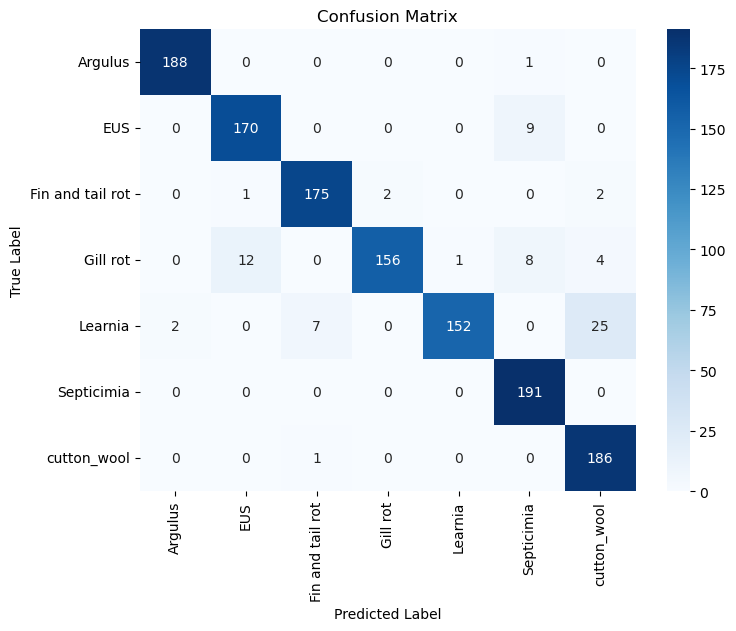

✅ Confusion matrix saved and displayed
Class Argulus:>>>>>>>> TP=188, FP=2, FN=1, TN=1102
Class EUS:>>>>>>>> TP=170, FP=13, FN=9, TN=1101
Class Fin and tail rot:>>>>>>>> TP=175, FP=8, FN=5, TN=1105
Class Gill rot:>>>>>>>> TP=156, FP=2, FN=25, TN=1110
Class Learnia:>>>>>>>> TP=152, FP=1, FN=34, TN=1106
Class Septicimia:>>>>>>>> TP=191, FP=18, FN=0, TN=1084
Class cutton_wool:>>>>>>>> TP=186, FP=31, FN=1, TN=1075


In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_true, y_pred)

n_classes=cm.shape[0]
class_names = test_ds.classes
# Initialize arrays
TP = np.zeros(n_classes, dtype=int)
FP = np.zeros(n_classes, dtype=int)
FN = np.zeros(n_classes, dtype=int)
TN = np.zeros(n_classes, dtype=int)

# Calculate per class
for i in range(n_classes):
    TP[i] = cm[i, i]
    FP[i] = cm[:, i].sum() - TP[i]
    FN[i] = cm[i, :].sum() - TP[i]
    TN[i] = cm.sum() - (TP[i] + FP[i] + FN[i])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_ds.classes,
    yticklabels=test_ds.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix Ensemble mv1.png", dpi=300, bbox_inches="tight")
plt.show()     # 👈 SHOW
plt.close()

print("✅ Confusion matrix saved and displayed")

# Display results
for i in range(n_classes):
    print(f"Class {class_names[i]}:>>>>>>>> TP={TP[i]}, FP={FP[i]}, FN={FN[i]}, TN={TN[i]}")